In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Dict, Any, List
import torch
import torch.nn.functional as F
import ray
import gymnasium as gym
from ray.rllib.algorithms.algorithm import Algorithm
import os
import sys
from copy import deepcopy

# Add project root to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.rllib_single_agent_wrapper import RLLibSingleAgentWrapper
from src.env.peer_group_environment import PeerGroupEnvironment
from ray import tune


In [2]:
# 1. Load RLlib PPO checkpoint
checkpoint_path = Path("../checkpoints/27-04-2026/balanced_by_effort_iter0099_mrl50_dbdosvul_27-04-13-27_eval_na_periodic").resolve()

if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint path {checkpoint_path} not found.")

# Initialize Ray if not already
if not ray.is_initialized():
    ray.init(ignore_reinit_error=True, local_mode=True)

# Training configuration values
env_config = {
    "start_agents": 100,
    "max_agents": 400,
    "max_steps": 600,
    "max_peer_group_size": 40,
    "n_groups": 10,
    "n_projects_per_step": 1,
    "max_projects_per_agent": 8,
    "reward_mode": "by_effort",
}

ENV_NAME = "peer_group_single_agent_fixed_population"

def env_creator(config):
    env = PeerGroupEnvironment(
        start_agents=env_config["start_agents"],
        max_agents=env_config["max_agents"],
        max_steps=env_config["max_steps"],
        max_peer_group_size=env_config["max_peer_group_size"],
        n_groups=env_config["n_groups"],
        n_projects_per_step=env_config["n_projects_per_step"],
        max_projects_per_agent=env_config["max_projects_per_agent"],
        reward_mode=env_config["reward_mode"],
    )
    return RLLibSingleAgentWrapper(env)

tune.register_env(ENV_NAME, env_creator)

# Restore algorithm from checkpoint
try:
    algo = Algorithm.from_checkpoint(str(checkpoint_path))
    print(f"Algorithm restored successfully from {checkpoint_path}")
except Exception as e:
    print(f"Failed to load algorithm from checkpoint: {e}")
    raise e

policy = algo.get_policy()
print(f"Policy Observation Space: {policy.observation_space}")
print(f"Policy Action Space: {policy.action_space}")

expected_obs_size = policy.observation_space.shape[0]
print(f"Expected observation size: {expected_obs_size}")

# Get the wrapper to use its methods
try:
    workers = algo.workers
    if callable(workers):
        workers = workers()
    wrapper_instance = workers.local_worker().env
except Exception:
    # Fallback if workers aren't accessible
    dummy_env = PeerGroupEnvironment(
        start_agents=env_config["start_agents"],
        max_agents=env_config["max_agents"],
        max_steps=env_config["max_steps"],
        max_peer_group_size=env_config["max_peer_group_size"],
        n_groups=env_config["n_groups"],
        n_projects_per_step=env_config["n_projects_per_step"],
        max_projects_per_agent=env_config["max_projects_per_agent"],
        reward_mode=env_config["reward_mode"]
    )
    wrapper_instance = RLLibSingleAgentWrapper(dummy_env)

# Build feature index map
feature_index = wrapper_instance.get_feature_index_map()
print(f"Feature index map built with {len(feature_index)} features.")


E:\PythonProjects\Hochschule\Game_of_Science_RL\.venv\Lib\site-packages\ray\_private\client_mode_hook.py:104: FutureWarning: `local_mode` is an experimental feature that is no longer maintained and will be removed in the near future. For debugging consider using the Ray distributed debugger.
  return func(*args, **kwargs)
2026-04-30 08:10:28,992	INFO worker.py:2013 -- Started a local Ray instance.
E:\PythonProjects\Hochschule\Game_of_Science_RL\.venv\Lib\site-packages\ray\_private\worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
E:\PythonProjects\Hochschule\Game_of_Science_RL\.venv\Lib\site-packages\ray\rllib\algorithms\algorithm.py:527: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warnin

:job_id:01000000
:actor_name:RolloutWorker
TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451


:job_id:01000000
:actor_name:RolloutWorker


:actor_name:RolloutWorker
TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451


:actor_name:RolloutWorker


...

:actor_name:RolloutWorker


:actor_name:RolloutWorker


TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451
:actor_name:RolloutWorker
TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451


:actor_name:RolloutWorker


TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451
Algorithm restored successfully from E:\PythonProjects\Hochschule\Game_of_Science_RL\checkpoints\27-04-2026\balanced_by_effort_iter0099_mrl50_dbdosvul_27-04-13-27_eval_na_periodic
Policy Observation Space: Box(-inf, inf, (451,), float32)
Policy Action Space: Dict('choose_project': Discrete(2), 'collaborate_with': Box(0.0, 1.0, (40,), float32), 'put_effort': Discrete(9))
Expected observation size: 451
Feature index map built with 451 features.


In [3]:
# 2. Generate fresh observations
print("\n--- Generating fresh observations ---")
fresh_observations = []
seeds = range(101, 111)
max_obs = 1000

for seed in seeds:
    obs, info = wrapper_instance.reset(seed=seed)
    fresh_observations.append(obs)
    
    terminated = truncated = False
    while not (terminated or truncated):
        # Use policy to get action
        action = algo.compute_single_action(obs, policy_id="default_policy")
        obs, reward, terminated, truncated, info = wrapper_instance.step(action)
        
        assert obs.shape[0] == expected_obs_size, f"Obs size mismatch: {obs.shape[0]} != {expected_obs_size}"
        fresh_observations.append(obs)
        
        if len(fresh_observations) >= max_obs:
            break
    if len(fresh_observations) >= max_obs:
        break

print(f"Collected {len(fresh_observations)} fresh observations.")



--- Generating fresh observations ---
TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451
Collected 655 fresh observations.


In [4]:
# 3. Define flat-vector sensitivity function
def compute_flat_logit_sensitivity(obs_vec, feature_idx, epsilon=1e-3):
    """
    Computes sensitivity of action head logits to small perturbations in a feature index.
    """
    model = policy.model
    model.eval()

    obs_orig = torch.tensor(obs_vec, dtype=torch.float32).unsqueeze(0)
    obs_pert = torch.tensor(obs_vec, dtype=torch.float32).unsqueeze(0)
    obs_pert[0, feature_idx] += epsilon

    with torch.no_grad():
        logits_orig, _ = model({"obs": obs_orig}, [], torch.tensor([1]))
        logits_pert, _ = model({"obs": obs_pert}, [], torch.tensor([1]))

    # Split logits by action heads
    act_space = policy.action_space
    heads = sorted(act_space.keys())
    
    split_indices = []
    current_idx = 0
    for head in heads:
        space = act_space[head]
        if hasattr(space, "n"):
            size = space.n
        elif hasattr(space, "shape") and space.shape:
            size = np.prod(space.shape)
        else:
            size = 1
        split_indices.append((current_idx, current_idx + int(size)))
        current_idx += int(size)

    results = {}
    for i, head in enumerate(heads):
        start, end = split_indices[i]
        l_orig = logits_orig[0, start:end]
        l_pert = logits_pert[0, start:end]
        
        if isinstance(act_space[head], gym.spaces.Discrete):
            p_orig = F.softmax(l_orig, dim=0)
            p_pert = F.softmax(l_pert, dim=0)
        else:
            # MultiBinary or Box heads use sigmoid
            p_orig = torch.sigmoid(l_orig)
            p_pert = torch.sigmoid(l_pert)
            
        delta_probs = p_pert - p_orig
        results[head] = {
            "mean_abs_delta_prob": torch.mean(torch.abs(delta_probs)).item()
        }
        
    return results


In [5]:
# 4. Batch Sensitivity Analysis
features_to_analyze = {
    "project_0 novelty": "observation.project_opportunities.project_0.novelty",
    "project_0 prestige": "observation.project_opportunities.project_0.prestige",
    "project_0 effort": "observation.project_opportunities.project_0.required_effort",
    "project_0 time": "observation.project_opportunities.project_0.time_window",
    "age": "observation.age",
    "accumulated_rewards": "observation.accumulated_rewards",
    "running_0 effort": "observation.running_projects.project_0.current_effort",
    "running_0 time_left": "observation.running_projects.project_0.time_left",
    "running_0 is_active": "observation.running_projects.project_0.is_active",
}

print("\n--- Running Sensitivity Analysis ---")
sensitivity_results = []

for label, feature_name in features_to_analyze.items():
    if feature_name not in feature_index:
        print(f"Warning: {feature_name} not found in feature index map. Skipping.")
        continue
        
    idx = feature_index[feature_name]
    print(f"Analyzing {label} (index {idx})...")
    
    for obs in fresh_observations:
        res = compute_flat_logit_sensitivity(obs, idx)
        for head, metrics in res.items():
            sensitivity_results.append({
                "feature": label,
                "head": head,
                "sensitivity": metrics["mean_abs_delta_prob"] / 1e-3
            })

df_sensitivity = pd.DataFrame(sensitivity_results)

# 5. Aggregate results
agg_sensitivity = df_sensitivity.groupby(["feature", "head"])["sensitivity"].mean().unstack()
print("\nAverage Normalized Sensitivity per Feature and Action Head:")
print(agg_sensitivity)



--- Running Sensitivity Analysis ---
Analyzing project_0 novelty (index 202)...
Analyzing project_0 prestige (index 203)...
Analyzing project_0 effort (index 204)...
Analyzing project_0 time (index 205)...
Analyzing age (index 1)...
Analyzing accumulated_rewards (index 0)...
Analyzing running_0 effort (index 206)...
Analyzing running_0 time_left (index 227)...
Analyzing running_0 is_active (index 207)...

Average Normalized Sensitivity per Feature and Action Head:
head                 choose_project  collaborate_with  put_effort
feature                                                          
accumulated_rewards        0.003192          0.001854    0.000510
age                        0.001142          0.000776    0.000249
project_0 effort           0.002888          0.000975    0.000332
project_0 novelty          0.003901          0.001013    0.000384
project_0 prestige         0.001358          0.001051    0.000391
project_0 time             0.002554          0.000861    0.000333
ru

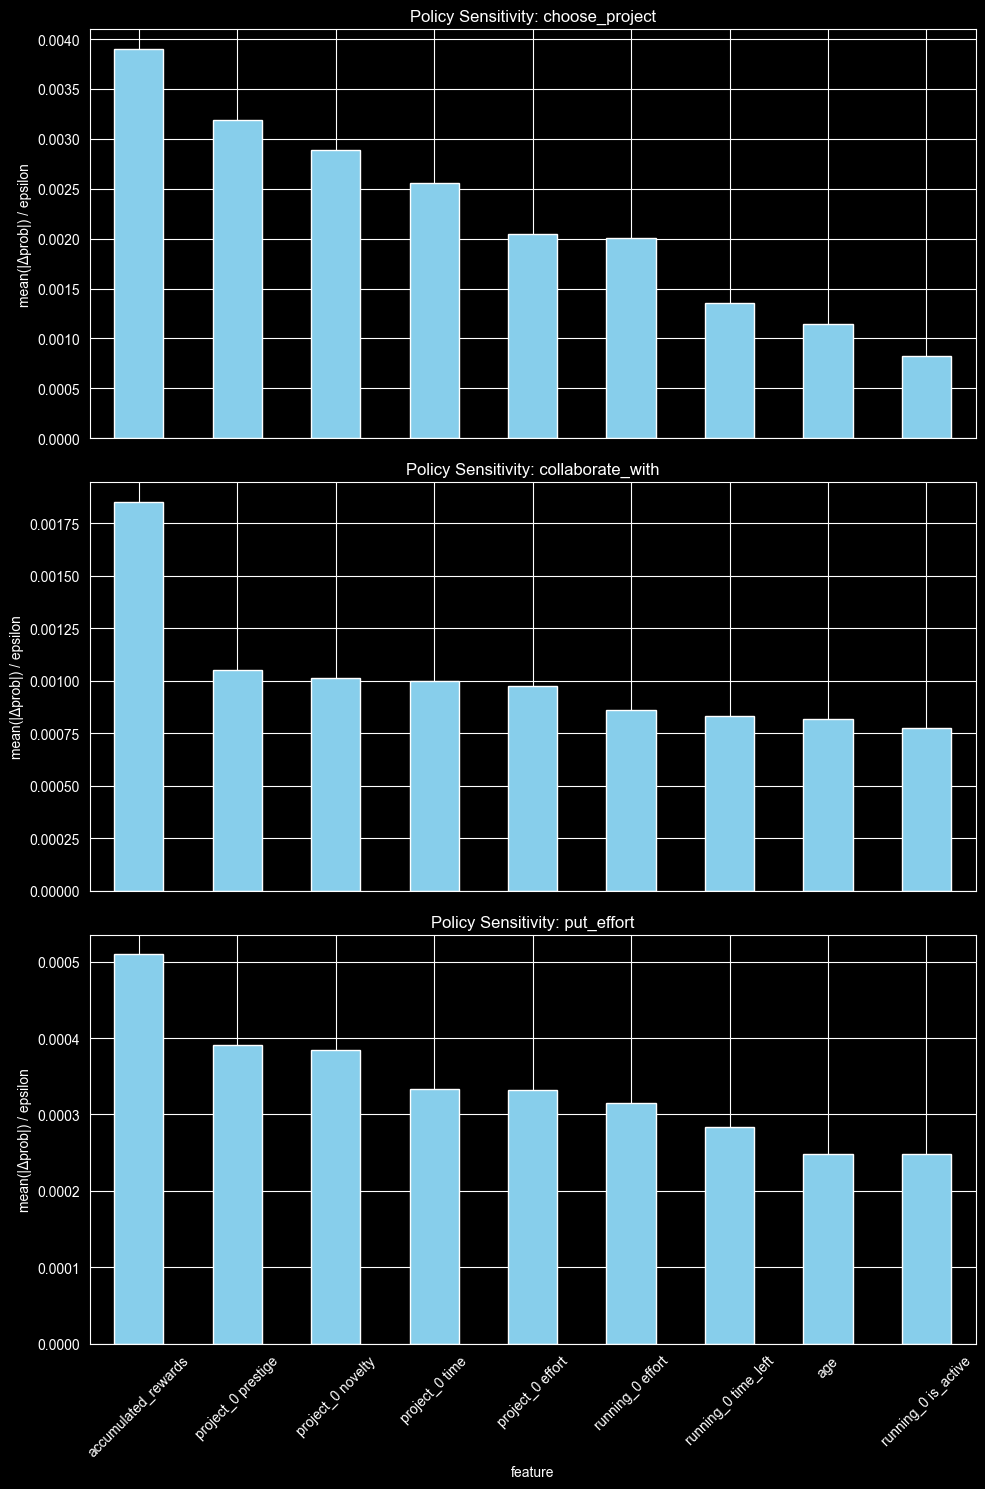

In [6]:
# 6. Visualization
heads = agg_sensitivity.columns
fig, axes = plt.subplots(len(heads), 1, figsize=(10, 5 * len(heads)), sharex=True)
if len(heads) == 1:
    axes = [axes]

for i, head in enumerate(heads):
    agg_sensitivity[head].sort_values(ascending=False).plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f"Policy Sensitivity: {head}")
    axes[i].set_ylabel("mean(|Δprob|) / epsilon")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
